In [1]:
# testrun = "false"
testrun = "true"
version = "1no_reasoning"

In [2]:
print(testrun)

true


# Evaluate with GPT-4

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pickle


In [5]:
import re
import openai
import pandas as pd
import random


import sys
import os
import tiktoken
from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
)  # for exponential backoff

In [6]:
from langchain_openai import AzureChatOpenAI
	
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.memory import ChatMessageHistory

from langchain.prompts.chat import ChatPromptTemplate
from langchain_core.runnables.history import RunnableWithMessageHistory

from langchain.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate

In [7]:
from brush_llm_funcs import brush_prepost_prob_llm, brush_get_probs_from_llm, brush_get_llm_responses

In [8]:
%load_ext dotenv
%dotenv /vast/palmer/home.mccleary/vs428/Documents/DischargeMe/hail-dischargeme/.env

In [9]:
# openai.api_type = "azure"
engine = "decile-gpt-4-128K"

In [10]:
os.environ['AZURE_OPENAI_ENDPOINT'] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ['AZURE_OPENAI_API_KEY'] = os.getenv("AZURE_OPENAI_KEY")
os.environ["OPENAI_API_VERSION"] = "2023-12-01-preview"

In [11]:
def num_tokens_from_string(string: str, encoding_name: str="cl100k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [12]:
from IPython.display import display, HTML

def add_line_breaks(text):
    return text.replace('\n', '<br>')


def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

In [13]:
data = pd.read_csv("/home/vs428/project/Uncertainty_data/all_cases.csv", sep="|",  engine="c")

In [14]:
data['case'] = data['case'].str.replace("“", '"')
data['case'] = data['case'].str.replace("”", '"')
data['case'] = data['case'].str.replace("’", "'")
data['case'] = data['case'].str.replace("½", "1/2")
data['case'] = data['case'].str.replace("–", "-")

In [15]:
for case in data['case'].tolist():
    try:
        case.encode('ascii')
    except UnicodeDecodeError:
        print("it was not a ascii-encoded unicode string")

In [16]:
with pd.option_context("display.max_colwidth", 2000):
    display(data.sample(5))

,index,case_id,case_type,probability,differential,case,lab_value_text,q1,q2,pos_lr,neg_lr
29,29,4,PNEUMONIA,high,HCAP,"A 86-year-old woman is transferred to the emergency department from her nursing home. Over the last two days she has developed a new cough, fever and has become increasingly confused. At baseline she has mild cognitive impairment, but is normally able to participate in a simple conversation. Now she is lethargic and her speech is illegible. The nursing home transfer record indicates that she has been coughing up dark green sputum. \n\nHer past medical history is remarkable for hypertension, diet-controlled diabetes, coronary artery disease, a remote stroke (which left her with left-sided paralysis) and mild dementia. She is a non-smoker and does not drink alcohol. \n\nOn physical examination, her vital signs are temperature 39.5 C; pulse 118 / minute, blood pressure 120/96 / minute; respiratory rate 30 / minute. Her cardiac exam reveals a regular rate and rhythm with no murmurs, gallops or rubs. On auscultation of her chest, she has crackles in the left base. Her oropharynx and neck exam reveal no abnormalities. Her extremities have no swelling, and there are no visible rashes.",A chest xray is performed. The radiologist interprets the chest xray as demonstrating a large consolidation of the left lower lobe with air bronchograms. Studies show that a chest x-ray showing consolidation is predictive for pneumonia with a sensitivity of 70% and specificity of 78% with a positive likelihood ratio of 3.2 and a negative likelihood ratio of 0.4.,What is the probability that this patient has pneumonia?,What is the probability that this patient has pneumonia?,3.20,0.40
33,33,4,Pulmonary Embolism,low,Asthma,"A 45 year old female presents with a 6 day history of difficulty breathing. ""It feels as though I'm breathing through a wet towel."" The patient denies any chest pain. She has been using a Ventolin inhaler without significant relief for the past three days. She indicates that she has been diagnosed with asthma by her family physician without formal testing; however, her condition is so mild that she infrequently (less than once a year) requires bronchodilators. ""I wonder if my puffer is useless, I got it last year and haven't touched it since."" \n\nPast medical history is only significant for asthma. The patient is a smoker but has cut down to less than a quarter package of cigarettes per day. She takes a multivitamin and a vitamin D tablet daily.\n\nOn examination, her temperature is 36.9C; pulse 106 / minute; blood pressure 100/70mmHg; and respiratory rate 22 / minute. She has equal strong pulses in all limbs. Her cardiac exam reveals no rubs, or murmurs. She has faint scattered wheezes in all lung fields. She can speak in full sentences, although she is occasionally interrupted by the need to cough and clear her throat. She has no calf tenderness or swelling.","A quantitative D-dimer is measured. The value is less than 500, which is reported as negative. Studies show that a quantitative d-dimer is predictive of pulmonary embolism with a sensitivity of 96% and a specificity of 45% with a positive likelihood ratio of 1.7 and a negative likelihood ratio of 0.09.",What is the probability that this patient has a pulmonary embolism?,What is the probability that this patient has a pulmonary embolism?,1.70,0.09
40,40,11,Pulmonary Embolism,high,PE,"A 29 yo female presents complaining of pleuritic chest pain. The pain has been waxing and waning for the last 24 hours. The patient does not recall any precipitating factors, specifically trauma or upper respiratory symptoms. When the pain did not resolve on it's own she sought medical attention. She noted that although she has no cough, when she walked up the stairs from the parking garage she was breathless at the top. This is unusual for her as she is active and in shape. Her biggest complaint is that she can only take tiny breaths, any deep inspiration intensifies the shar

In [17]:
llm = AzureChatOpenAI(
    deployment_name=engine
)

In [18]:
if testrun == "true":
    # data = data.sample(3)
    data = data.iloc[28:30]

# Run model

## Setup LangChain LLM Pipeline

In [19]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert physician estimating your confidence that a patient has a particular disease using only the clinical presentation you're reading.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

chain = prompt | llm

In [20]:
pretest_template = "{case}\n\n{question1} Let's think step by step. Think through your reasoning but do not include it in your answer. Your answer SHOULD ONLY include your final probability estimate. {format_instructions}"

posttest_template = "{labresult}\n\n{question2} Let's think step by step. Think through your reasoning but do not include it in your answer. Your answer SHOULD ONLY include your final probability estimate. {format_instructions}"

In [21]:
format_instructions = "Your response should be a SINGLE numerical probability estimate in the form of `The likelihood of [condition] is [number]%.` DO NOT give a range."

## Negative Lab Results

In [22]:
def compute_true_bayesian_update(pre_test, lr):
    if pre_test == 1:
        odds = ((pre_test)/(1-pre_test+ 10**-10)) * lr    
    else:
        odds = ((pre_test)/(1-pre_test)) * lr
    post_test = odds / (1 + odds)
    return post_test
    

In [23]:
data['case_type'].value_counts()

case_type
PNEUMONIA    2
Name: count, dtype: int64

In [24]:
neg_chat_histories = brush_prepost_prob_llm(chain, data,
                       pretest_template, posttest_template, format_instructions, 
                       positive=False,
                       verbose=False)


Current row: 28
Current row: 29


In [25]:
pickle.dump(neg_chat_histories, open(f"neg_chat_histories_{version}.pickle", "wb" ) )

In [26]:
neg_pretest_probs, neg_posttest_probs = brush_get_probs_from_llm(neg_chat_histories)

In [27]:
neg_pretest_responses, neg_posttest_responses = brush_get_llm_responses(neg_chat_histories)

In [28]:
neg_pretest_probs

[40.0, 90.0]

In [29]:
neg_probs_df = pd.DataFrame({"pretest_prob":neg_pretest_probs, "posttest_prob":neg_posttest_probs})

In [30]:
neg_response_df = pd.DataFrame({"pretest_llm_output":neg_pretest_responses, "posttest_llm_output":neg_posttest_responses})

In [31]:
neg_data_with_gpt = pd.concat([data, neg_probs_df, neg_response_df],axis=1)

In [32]:
# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "Asthma Exacerbation v CAP")
                                        & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]

neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "HCAP")
                                        & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]
# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

neg_data_with_gpt['true_posttest'] = neg_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['neg_lr']) * 100, axis=1)

neg_data_with_gpt['positive'] = False

In [33]:
neg_data_with_gpt.to_csv(f"all_cases_neg_gpt4_output_{version}.csv", index=False)

## Positive Lab Results

In [34]:
pos_chat_histories = brush_prepost_prob_llm(chain, data, 
                       pretest_template, posttest_template, format_instructions, 
                       positive=True,
                       verbose=False)


Current row: 28
Current row: 29


In [35]:
pickle.dump(pos_chat_histories, open(f"pos_chat_histories_{version}.pickle", "wb" ) )

In [36]:
pos_pretest_probs, pos_posttest_probs = brush_get_probs_from_llm(pos_chat_histories)

In [37]:
pos_pretest_responses, pos_posttest_responses = brush_get_llm_responses(pos_chat_histories)

In [38]:
pos_pretest_probs

[70.0, 90.0]

In [39]:
pos_probs_df = pd.DataFrame({"pretest_prob":pos_pretest_probs, "posttest_prob":pos_posttest_probs})

In [40]:
pos_response_df = pd.DataFrame({"pretest_llm_output": pos_pretest_responses, "posttest_llm_output": pos_posttest_responses})

In [41]:
pos_data_with_gpt = pd.concat([data, pos_probs_df, pos_response_df],axis=1)

In [42]:
# drop the Pulmonary Embolism test cases from the positive lab df, since they have hard coded "negative" d-dimer values
pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['probability'] == "low")
& (pos_data_with_gpt['case_type'] == "Pulmonary Embolism"))]

In [43]:
# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "URI")
                                        & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "PCP v ILI")
                                        & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

In [44]:
pos_data_with_gpt['true_posttest'] = pos_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['pos_lr']) * 100, axis=1)


In [45]:
pos_data_with_gpt['positive'] = True


In [46]:
pos_data_with_gpt.to_csv(f"all_cases_pos_gpt4_output_{version}.csv", index=False)

# Compute Bayesian Change Score

In [47]:
data_with_gpt = pd.concat([pos_data_with_gpt, neg_data_with_gpt], axis=0)

In [48]:
data_with_gpt['bayes_diff'] = data_with_gpt['true_posttest'] - data_with_gpt['posttest_prob']

In [49]:
data_with_gpt.to_csv(f"all_cases_posneg_gpt4_output_{version}.csv", index=False)

# Plot

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
results = pd.DataFrame([(neg_data_with_gpt['true_posttest'] - neg_data_with_gpt['posttest_prob']).tolist(), 
                        (pos_data_with_gpt['true_posttest'] - pos_data_with_gpt['posttest_prob']).tolist()]).T.rename({0:"negative test", 1:"positive test"}, axis=1)

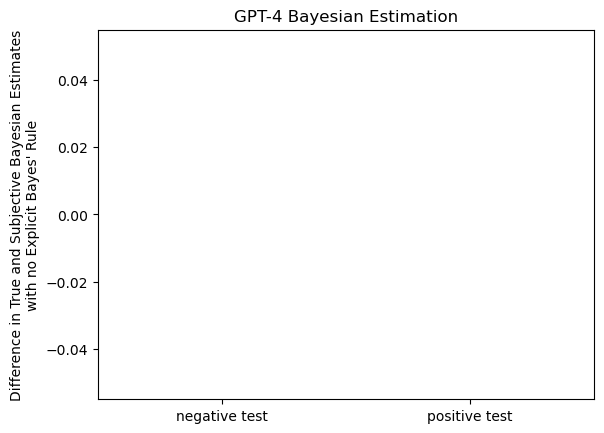

In [52]:
fig = sns.barplot(results.mean(), )
plt.ylabel("Difference in True and Subjective Bayesian Estimates\nwith no Explicit Bayes' Rule")
plt.title("GPT-4 Bayesian Estimation")
plt.savefig(f"difference_{version}.png", bbox_inches="tight")

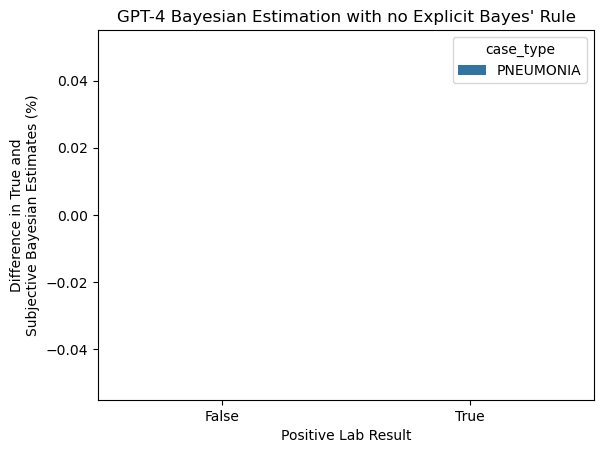

In [53]:
fig = sns.barplot(data_with_gpt, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("GPT-4 Bayesian Estimation with no Explicit Bayes' Rule")
plt.savefig(f"difference_by_condition_{version}.png", bbox_inches="tight")